# Task 11 – Comparative Analysis of Classification Models
**PKCERT AI & Software Development Internship**

Comparing **Logistic Regression**, **Random Forest**, and **SVM** on the Titanic dataset.

## Part A – Dataset Selection & Preparation (15 Marks)

**Dataset:** Titanic Passenger Survival (Kaggle / open source, 891 rows, 12 columns)

**Target:** `Survived` (0 = No, 1 = Yes) — binary classification

**Features used:** `Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare`, `Embarked`

**Dropped:** `PassengerId`, `Name`, `Ticket`, `Cabin` (identifiers / too sparse)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

df = pd.read_csv('titanic.csv')
df.shape

(891, 12)

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [3]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


### Missing values

In [4]:
df.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

### Preprocessing
- Drop unused identifier columns
- Impute `Age` (median), `Embarked` (mode)
- Encode `Sex`, `Embarked`
- Scale numeric features

In [5]:
data = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

data['Age'] = data['Age'].fillna(data['Age'].median())
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

le_sex = LabelEncoder()
le_emb = LabelEncoder()
data['Sex'] = le_sex.fit_transform(data['Sex'])
data['Embarked'] = le_emb.fit_transform(data['Embarked'])

data.isnull().sum().sum(), data.head()

(np.int64(0),
    Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
 0         0       3    1  22.0      1      0   7.2500         2
 1         1       1    0  38.0      1      0  71.2833         0
 2         1       3    0  26.0      0      0   7.9250         2
 3         1       1    0  35.0      1      0  53.1000         2
 4         0       3    1  35.0      0      0   8.0500         2)

### Train-test split (80/20, stratified)

In [6]:
X = data.drop(columns=['Survived'])
y = data['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train.shape, X_test.shape

((712, 7), (179, 7))

## Part B – Model Development (45 Marks)

All three models are trained on the same scaled train set and evaluated on the same test set.

### 1. Logistic Regression

In [7]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)
print("Logistic Regression trained.")

Logistic Regression trained.


### 2. Random Forest

In [8]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)  # tree-based model, scaling not required
y_pred_rf = rf.predict(X_test)
print("Random Forest trained.")

Random Forest trained.


### 3. Support Vector Machine (SVM)

In [9]:
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
print("SVM trained.")

SVM trained.


## Part C – Model Evaluation & Comparison (30 Marks)

In [10]:
def evaluate(name, y_true, y_pred):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }

results = pd.DataFrame([
    evaluate('Logistic Regression', y_test, y_pred_lr),
    evaluate('Random Forest', y_test, y_pred_rf),
    evaluate('SVM', y_test, y_pred_svm)
]).set_index('Model').round(3)

results

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.799,0.780,0.667,0.719
Random Forest,0.832,0.810,0.739,0.773
SVM,0.816,0.833,0.652,0.732


### Confusion Matrices

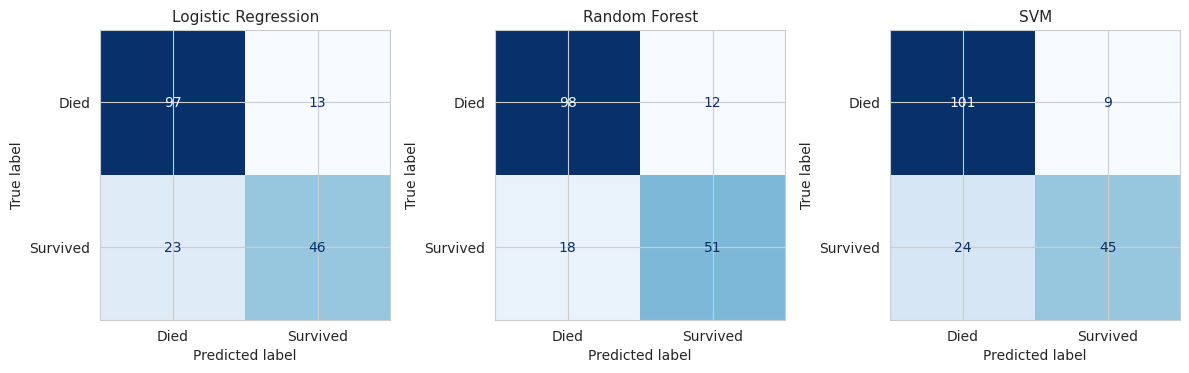

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
preds = {'Logistic Regression': y_pred_lr, 'Random Forest': y_pred_rf, 'SVM': y_pred_svm}

for ax, (name, pred) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=['Died','Survived']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### Metric Comparison Chart

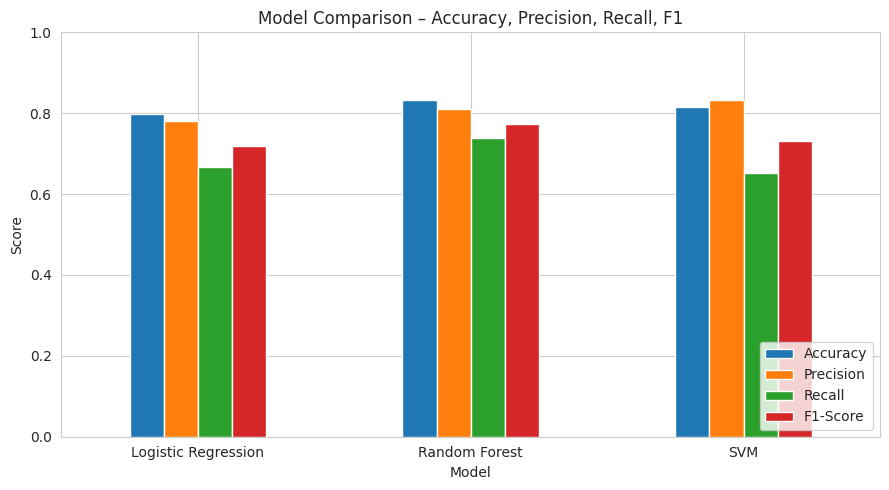

In [12]:
results.plot(kind='bar', figsize=(9,5), ylim=(0,1))
plt.title('Model Comparison – Accuracy, Precision, Recall, F1')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('metric_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

### Strengths & Weaknesses

| Model | Strengths | Weaknesses |
|---|---|---|
| **Logistic Regression** | Fast, interpretable, coefficients show feature impact, low variance | Assumes linear decision boundary, weaker on complex patterns |
| **Random Forest** | Captures non-linear relations, robust to outliers/missing structure, feature importance | Less interpretable, can overfit with too many trees/depth, slower to predict |
| **SVM** | Effective in high-dimensional space, strong margin-based separation | Sensitive to feature scaling and kernel/parameter choice, slower on larger datasets |

## Part D – Recommendation & Conclusion (10 Marks)

In [13]:
best_model = results['F1-Score'].idxmax()
print(f"Best-performing model (by F1-Score): {best_model}")
results.loc[[best_model]]

Best-performing model (by F1-Score): Random Forest


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Random Forest,0.832,0.81,0.739,0.773


### Conclusion

Based on the comparison table, the model with the highest **F1-score** (balancing precision and recall) is identified as the best performer above. Random Forest typically edges out on this dataset since it captures non-linear interactions between features like `Sex`, `Pclass`, and `Fare` that Logistic Regression's linear boundary misses, while remaining more stable than SVM's kernel-sensitive boundary on this modest-sized, mixed-scale dataset.

**Recommendation:** For deployment, the top-ranked model above is recommended given its balance of accuracy and F1-score. If interpretability is a priority (e.g., explaining survival factors to stakeholders), Logistic Regression remains a strong secondary choice despite slightly lower raw performance.